# COMP6237 — Semantic Spaces visual demo

This notebook follows the lecture flow in **Lecture 10: Semantic Spaces** and turns the slide ideas into small visual demos.

It uses the same classic 9-document example from the slides:
- `m1`–`m5`: human/computer/system topic
- `g1`–`g4`: graph/trees topic

The sections are aligned to the slide sequence:
1. problem setup and raw strings  
2. term–document matrix / TF-IDF  
3. SVD and truncated SVD  
4. document space and word space  
5. cosine similarity in latent space  
6. LSI document retrieval  
7. limitations: polysemy and word order  
8. visual words and a tiny multimodal shared space


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from ipywidgets import interact, IntSlider

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_colwidth", None)
np.set_printoptions(precision=3, suppress=True)


## 1. Slide: Problem — a set of strings

These are the 9 document titles from the lecture slides.  
Intuitively, the first 5 belong to one topic, and the last 4 belong to another topic.


In [2]:
doc_names = ["m1","m2","m3","m4","m5","g1","g2","g3","g4"]

docs = [
    "Human machine interface for ABC computer applications",
    "A survey of user opinion of computer system response time",
    "The EPS user interface management system",
    "System and human system engineering testing of EPS",
    "Relation of user perceived response time to error measurement",
    "The generation of random, binary, ordered trees",
    "The intersection graph of paths in trees",
    "Graph minors IV: Widths of trees and well-quasi-ordering",
    "Graph minors: A survey",
]

df_docs = pd.DataFrame({"doc": doc_names, "title": docs})
display(df_docs)


,doc,title
0,m1,Human machine interface for ABC computer applications
1,m2,A survey of user opinion of computer system response time
2,m3,The EPS user interface management system
3,m4,System and human system engineering testing of EPS
4,m5,Relation of user perceived response time to error measurement
5,g1,"The generation of random, binary, ordered trees"
6,g2,The intersection graph of paths in trees
7,g3,Graph minors IV: Widths of trees and well-quasi-ordering
8,g4,Graph minors: A survey


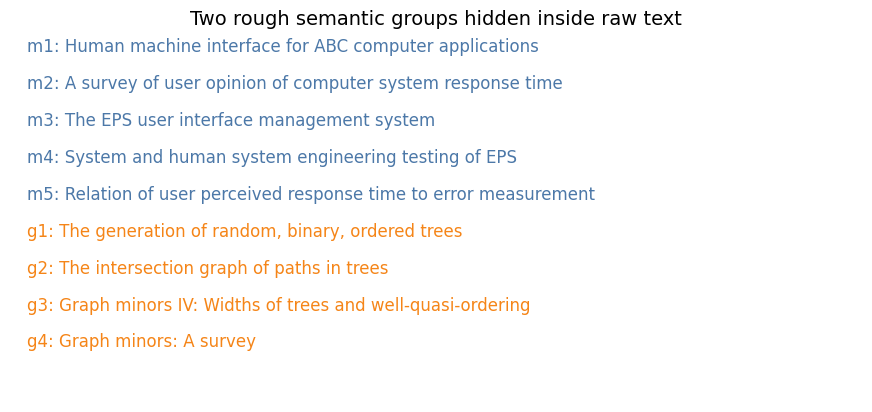

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.axis("off")

for i, (name, text) in enumerate(zip(doc_names, docs)):
    color = "#4C78A8" if name.startswith("m") else "#F58518"
    ax.text(0.02, 0.95 - i*0.1, f"{name}: {text}", fontsize=12, color=color, transform=ax.transAxes)

ax.set_title("Two rough semantic groups hidden inside raw text", fontsize=14)
plt.show()


## 2. Slide: Semantic spaces — represent documents as vectors

We first build a **term–document matrix** using TF-IDF.  
Rows are words, columns are documents.


In [4]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=12,
    sublinear_tf=True
)

X = vectorizer.fit_transform(docs)
terms = vectorizer.get_feature_names_out()
A = X.toarray().T   # words x docs, aligned with slide notation

print("Matrix shape (words x docs):", A.shape)
pd.DataFrame(A, index=terms, columns=doc_names).round(2)


Matrix shape (words x docs): (12, 9)


,m1,m2,m3,m4,m5,g1,g2,g3,g4
computer,0.58,0.46,0.00,0.00,0.00,0.0,0.00,0.00,0.00
eps,0.00,0.00,0.60,0.71,0.00,0.0,0.00,0.00,0.00
graph,0.00,0.00,0.00,0.00,0.00,0.0,0.71,0.55,0.52
human,0.58,0.00,0.00,0.71,0.00,0.0,0.00,0.00,0.00
interface,0.58,0.00,0.60,0.00,0.00,0.0,0.00,0.00,0.00
minors,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.63,0.60
perceived,0.00,0.00,0.00,0.00,0.58,0.0,0.00,0.00,0.00
response,0.00,0.46,0.00,0.00,0.49,0.0,0.00,0.00,0.00
survey,0.00,0.46,0.00,0.00,0.00,0.0,0.00,0.00,0.60
time,0.00,0.46,0.00,0.00,0.49,0.0,0.00,0.00,0.00


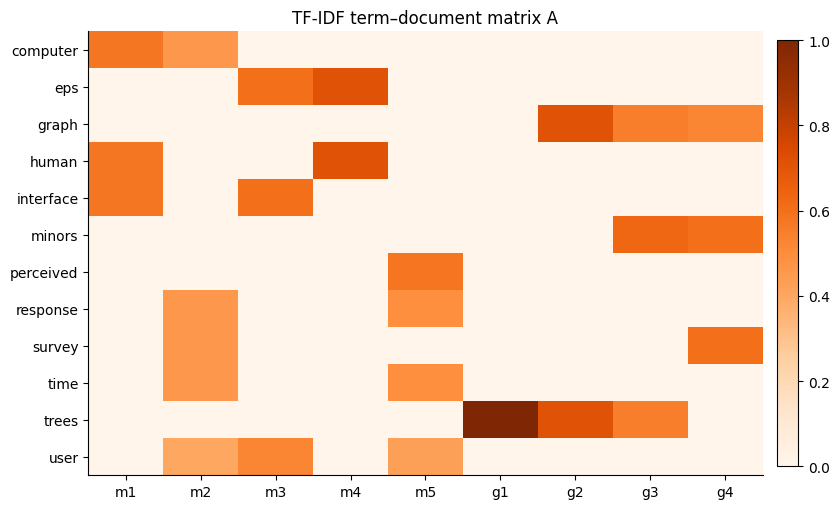

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
im = ax.imshow(A, cmap="Oranges", aspect="auto")
ax.set_yticks(np.arange(len(terms)))
ax.set_yticklabels(terms)
ax.set_xticks(np.arange(len(doc_names)))
ax.set_xticklabels(doc_names)
ax.set_title("TF-IDF term–document matrix A")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()


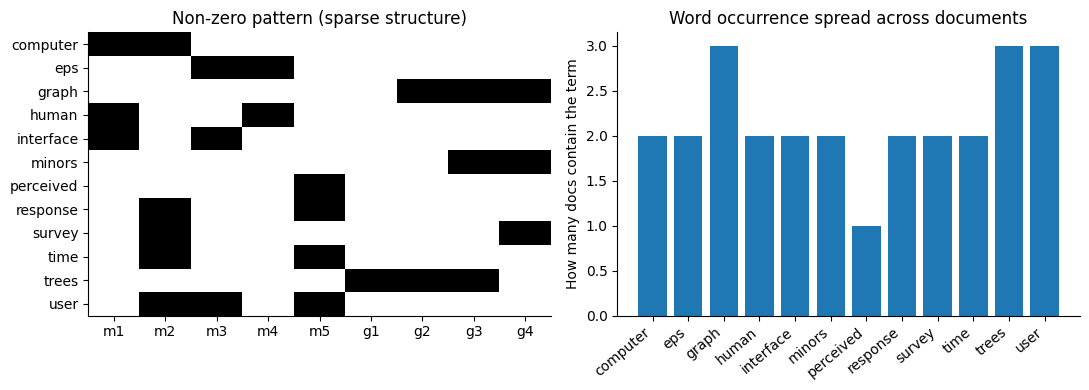

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(A != 0, cmap="gray_r", aspect="auto")
axes[0].set_title("Non-zero pattern (sparse structure)")
axes[0].set_yticks(np.arange(len(terms)))
axes[0].set_yticklabels(terms)
axes[0].set_xticks(np.arange(len(doc_names)))
axes[0].set_xticklabels(doc_names)

axes[1].bar(range(len(terms)), (A != 0).sum(axis=1))
axes[1].set_xticks(range(len(terms)))
axes[1].set_xticklabels(terms, rotation=40, ha="right")
axes[1].set_ylabel("How many docs contain the term")
axes[1].set_title("Word occurrence spread across documents")
plt.tight_layout()
plt.show()


## 3. Slides: SVD and truncated SVD

LSA assumes the matrix is noisy / too sparse, so we approximate it with a **lower-rank matrix**.


In [7]:
U, s, VT = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)

print("Singular values:")
print(np.round(s, 3))


Singular values:
[1.616 1.422 1.216 1.031 0.843 0.721 0.571 0.438 0.271]


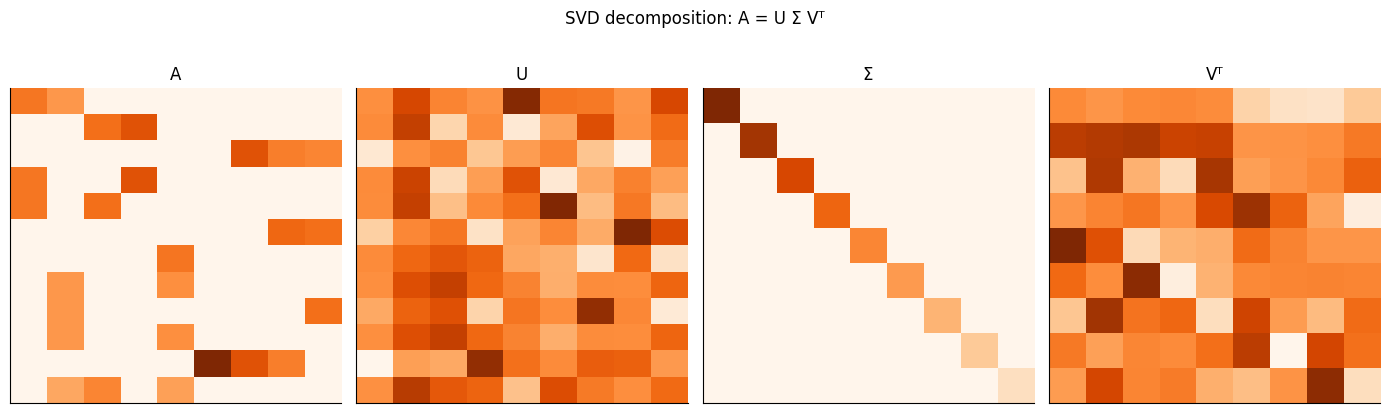

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
mats = [A, U, Sigma, VT]
titles = ["A", "U", "Σ", "Vᵀ"]

for ax, M, ttl in zip(axes, mats, titles):
    im = ax.imshow(M, cmap="Oranges", aspect="auto")
    ax.set_title(ttl)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("SVD decomposition: A = U Σ Vᵀ", y=1.02)
plt.tight_layout()
plt.show()


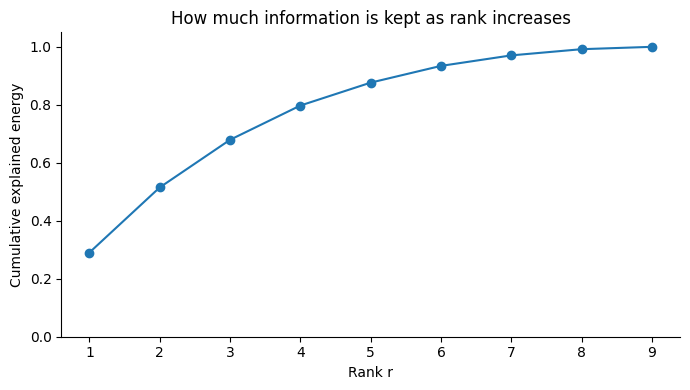

In [9]:
energy = np.cumsum(s**2) / np.sum(s**2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(s)+1), energy, marker="o")
ax.set_xlabel("Rank r")
ax.set_ylabel("Cumulative explained energy")
ax.set_title("How much information is kept as rank increases")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [10]:
def show_rank_approx(r=2):
    Ur = U[:, :r]
    Sigmar = np.diag(s[:r])
    VTr = VT[:r, :]
    Ahat = Ur @ Sigmar @ VTr
    err = np.linalg.norm(A - Ahat, ord="fro")

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    mats = [Ur, Sigmar, VTr, Ahat]
    titles = [f"U_r ({Ur.shape[0]}x{Ur.shape[1]})", f"Σ_r ({r}x{r})", f"V_rᵀ ({VTr.shape[0]}x{VTr.shape[1]})", "Reconstruction Â"]
    for ax, M, ttl in zip(axes, mats, titles):
        ax.imshow(M, cmap="Oranges", aspect="auto")
        ax.set_title(ttl)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle(f"Truncated SVD with rank r={r}  |  Frobenius error={err:.3f}", y=1.02)
    plt.tight_layout()
    plt.show()

interact(show_rank_approx, r=IntSlider(min=1, max=min(8, len(s)), step=1, value=4, description="rank"));


interactive(children=(IntSlider(value=4, description='rank', max=8, min=1), Output()), _dom_classes=('widget-i…

## 4. Slides: document concepts and word concepts

After truncation, each document and each word can be represented in the same latent dimensionality `r`, but in different spaces.


In [11]:
r = 2
Ur = U[:, :r]
Sigmar = np.diag(s[:r])
VTr = VT[:r, :]

doc_coords = (Sigmar @ VTr).T          # docs x r
word_coords = Ur @ Sigmar              # words x r

print("Document coordinates shape:", doc_coords.shape)
print("Word coordinates shape:", word_coords.shape)


Document coordinates shape: (9, 2)
Word coordinates shape: (12, 2)


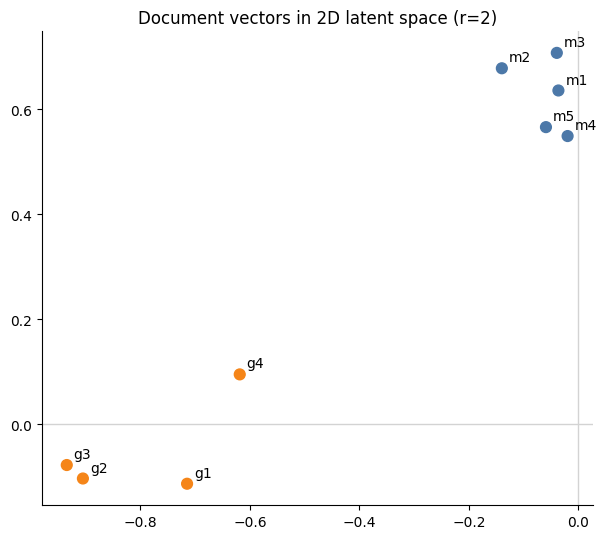

In [12]:
fig, ax = plt.subplots(figsize=(6.2, 5.5))
colors = ["#4C78A8" if d.startswith("m") else "#F58518" for d in doc_names]
ax.scatter(doc_coords[:,0], doc_coords[:,1], c=colors, s=60)

for i, label in enumerate(doc_names):
    ax.annotate(label, (doc_coords[i,0], doc_coords[i,1]), xytext=(5,5), textcoords="offset points")

ax.axhline(0, color="lightgray", lw=1)
ax.axvline(0, color="lightgray", lw=1)
ax.set_title("Document vectors in 2D latent space (r=2)")
plt.tight_layout()
plt.show()


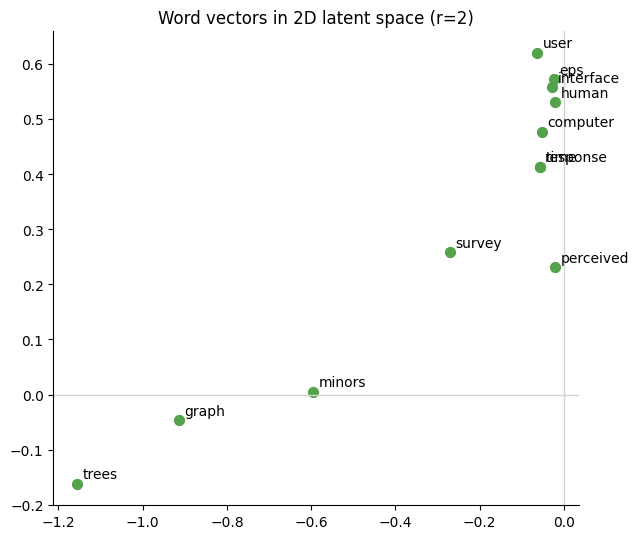

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(word_coords[:,0], word_coords[:,1], s=50, c="#54A24B")

for i, label in enumerate(terms):
    ax.annotate(label, (word_coords[i,0], word_coords[i,1]), xytext=(4,4), textcoords="offset points")

ax.axhline(0, color="lightgray", lw=1)
ax.axvline(0, color="lightgray", lw=1)
ax.set_title("Word vectors in 2D latent space (r=2)")
plt.tight_layout()
plt.show()


## 5. Slides: cosine similarity in the latent space

Now semantic similarity is measured geometrically, often with **cosine similarity**.


In [14]:
def sim_report(a_name, b_name, vecs, names):
    i = names.index(a_name)
    j = names.index(b_name)
    s = cosine_similarity(vecs[[i]], vecs[[j]])[0,0]
    return f"{a_name} vs {b_name}: {s:.2f}"

print("Document similarities:")
print(sim_report("m1", "m2", doc_coords, doc_names))
print(sim_report("g1", "g2", doc_coords, doc_names))
print(sim_report("g1", "m1", doc_coords, doc_names))

print("\nWord similarities:")
term_list = list(terms)
pairs = [("human", "interface"), ("human", "user"), ("graph", "trees")]
for a, b in pairs:
    if a in term_list and b in term_list:
        print(sim_report(a, b, word_coords, term_list))


Document similarities:
m1 vs m2: 0.99
g1 vs g2: 1.00
g1 vs m1: -0.10

Word similarities:
human vs interface: 1.00
human vs user: 1.00
graph vs trees: 1.00


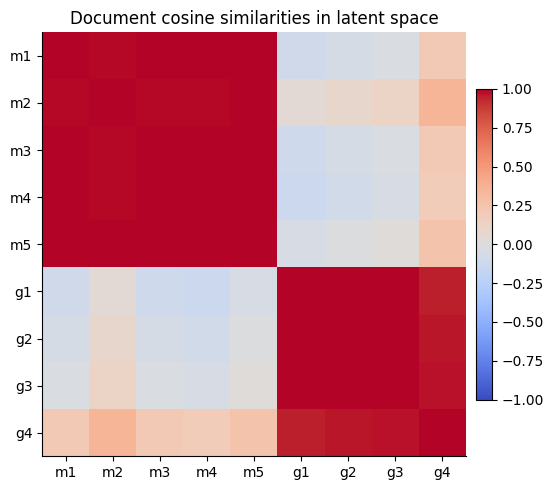

In [15]:
# Pairwise document cosine similarity heatmap
doc_sim = cosine_similarity(doc_coords)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(doc_sim, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(doc_names)))
ax.set_xticklabels(doc_names)
ax.set_yticks(np.arange(len(doc_names)))
ax.set_yticklabels(doc_names)
ax.set_title("Document cosine similarities in latent space")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()


## 6. Slide: What do the concepts mean?

A simple way to inspect a concept is to look at the **largest positive / negative word weights** in each latent dimension.


In [16]:
def top_words_per_concept(UrSigma, terms, topn=5):
    rows = []
    for k in range(UrSigma.shape[1]):
        weights = UrSigma[:, k]
        pos_idx = np.argsort(weights)[::-1][:topn]
        neg_idx = np.argsort(weights)[:topn]
        rows.append({
            "concept": k,
            "top positive": ", ".join([terms[i] for i in pos_idx]),
            "top negative": ", ".join([terms[i] for i in neg_idx]),
        })
    return pd.DataFrame(rows)

display(top_words_per_concept(word_coords, terms, topn=5))


,concept,top positive,top negative
0,0,"perceived, human, eps, interface, computer","trees, graph, minors, survey, user"
1,1,"user, eps, interface, human, computer","trees, graph, minors, perceived, survey"


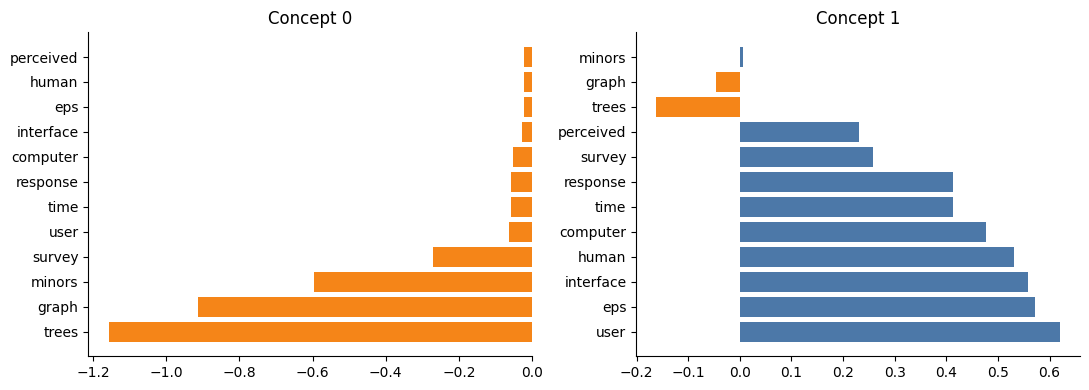

In [17]:
fig, axes = plt.subplots(1, r, figsize=(11, 4))
if r == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    weights = word_coords[:, k]
    order = np.argsort(np.abs(weights))[::-1]
    ax.barh(np.array(terms)[order], weights[order], color=["#4C78A8" if w >= 0 else "#F58518" for w in weights[order]])
    ax.set_title(f"Concept {k}")
plt.tight_layout()
plt.show()


## 7. Slide: LSI — project a query into the document space

Given a query, build its TF-IDF vector, project it into the latent space, then compare it with document vectors.


In [18]:
query = ["user response time"]
q = vectorizer.transform(query).toarray().T   # words x 1
q_latent = (q.T @ Ur) @ np.linalg.inv(Sigmar) # query in document latent space; shape 1 x r

sims = cosine_similarity(q_latent, doc_coords)[0]
ranking = pd.DataFrame({"doc": doc_names, "title": docs, "cosine_with_query": sims}).sort_values("cosine_with_query", ascending=False)
display(ranking)


,doc,title,cosine_with_query
4,m5,Relation of user perceived response time to error measurement,0.999965
0,m1,Human machine interface for ABC computer applications,0.999252
2,m3,The EPS user interface management system,0.999186
3,m4,System and human system engineering testing of EPS,0.998190
1,m2,A survey of user opinion of computer system response time,0.994227
8,g4,Graph minors: A survey,0.245006
7,g3,Graph minors IV: Widths of trees and well-quasi-ordering,0.012492
6,g2,The intersection graph of paths in trees,-0.018265
5,g1,"The generation of random, binary, ordered trees",-0.061887


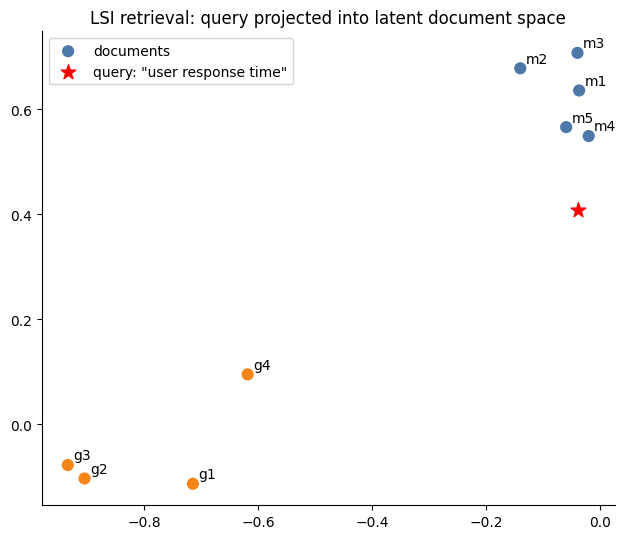

In [19]:
fig, ax = plt.subplots(figsize=(6.4, 5.5))
colors = ["#4C78A8" if d.startswith("m") else "#F58518" for d in doc_names]
ax.scatter(doc_coords[:,0], doc_coords[:,1], c=colors, s=60, label="documents")
for i, label in enumerate(doc_names):
    ax.annotate(label, (doc_coords[i,0], doc_coords[i,1]), xytext=(4,4), textcoords="offset points")
ax.scatter(q_latent[0,0], q_latent[0,1], c="red", s=120, marker="*", label='query: "user response time"')
ax.legend()
ax.set_title("LSI retrieval: query projected into latent document space")
plt.tight_layout()
plt.show()


## 8. Slide: Problems — polysemy and word order

LSA is a bag-of-words method, so word order is ignored.


In [20]:
commands = [
    "What is the time",
    "What is the day",
    "What time is the meeting",
    "Cancel the meeting",
]
command_names = ["s1", "s2", "s3", "s4"]

cv_uni = CountVectorizer()
B_uni = cv_uni.fit_transform(commands).toarray()

pd.DataFrame(B_uni, index=command_names, columns=cv_uni.get_feature_names_out())


,cancel,day,is,meeting,the,time,what
s1,0,0,1,0,1,1,1
s2,0,1,1,0,1,0,1
s3,0,0,1,1,1,1,1
s4,1,0,0,1,1,0,0


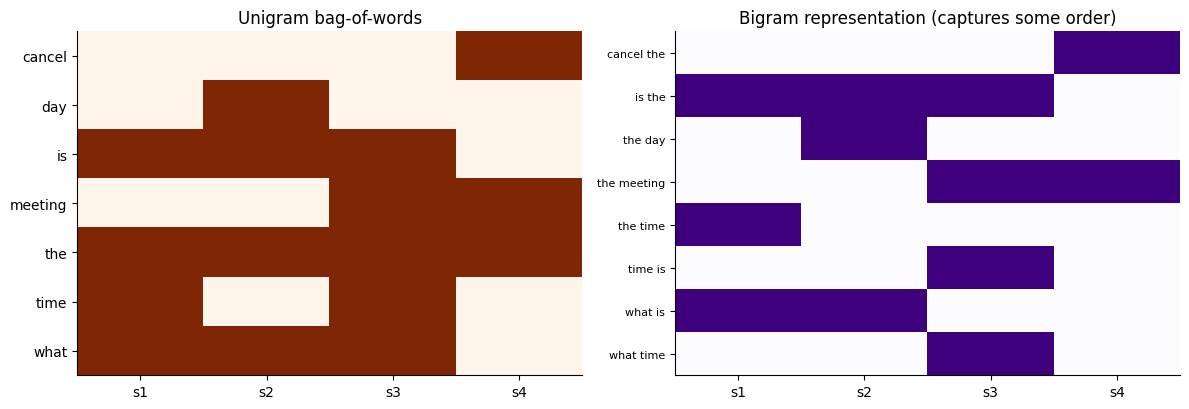

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].imshow(B_uni.T, cmap="Oranges", aspect="auto")
axes[0].set_yticks(np.arange(len(cv_uni.get_feature_names_out())))
axes[0].set_yticklabels(cv_uni.get_feature_names_out())
axes[0].set_xticks(np.arange(len(command_names)))
axes[0].set_xticklabels(command_names)
axes[0].set_title("Unigram bag-of-words")

cv_bi = CountVectorizer(ngram_range=(2,2))
B_bi = cv_bi.fit_transform(commands).toarray()
axes[1].imshow(B_bi.T, cmap="Purples", aspect="auto")
axes[1].set_yticks(np.arange(len(cv_bi.get_feature_names_out())))
axes[1].set_yticklabels(cv_bi.get_feature_names_out(), fontsize=8)
axes[1].set_xticks(np.arange(len(command_names)))
axes[1].set_xticklabels(command_names)
axes[1].set_title("Bigram representation (captures some order)")

plt.tight_layout()
plt.show()


In [22]:
# Polysemy example
poly_docs = [
    "He is very fit and healthy",
    "This shirt is a good fit",
    "The athlete is fit",
    "We need a better fit for the model"
]

cv_poly = TfidfVectorizer(stop_words="english")
P = cv_poly.fit_transform(poly_docs).toarray()
terms_poly = cv_poly.get_feature_names_out()

display(pd.DataFrame(P, columns=terms_poly).round(2))
print("The word 'fit' appears in different meanings, but bag-of-words treats it as one feature.")


,athlete,better,fit,good,healthy,model,need,shirt
0,0.00,0.00,0.46,0.00,0.89,0.00,0.00,0.00
1,0.00,0.00,0.35,0.66,0.00,0.00,0.00,0.66
2,0.89,0.00,0.46,0.00,0.00,0.00,0.00,0.00
3,0.00,0.55,0.29,0.00,0.00,0.55,0.55,0.00


The word 'fit' appears in different meanings, but bag-of-words treats it as one feature.


## 9. Slides: Visual words — images can also become bags of 'visual terms'

We build a tiny synthetic example with counts of shapes.


In [23]:
shape_vocab = ["circle", "square", "triangle", "star"]

# two toy images described by visual word counts
image_counts = pd.DataFrame(
    [
        [2, 3, 0, 0],   # image A
        [0, 0, 5, 0],   # image B
        [1, 2, 0, 0],   # image C
    ],
    index=["img_A", "img_B", "img_C"],
    columns=shape_vocab
)

display(image_counts)


,circle,square,triangle,star
img_A,2,3,0,0
img_B,0,0,5,0
img_C,1,2,0,0


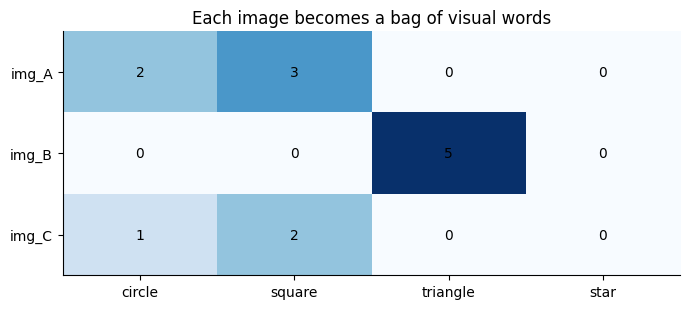

In [24]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.imshow(image_counts.values, cmap="Blues", aspect="auto")
ax.set_xticks(np.arange(len(shape_vocab)))
ax.set_xticklabels(shape_vocab)
ax.set_yticks(np.arange(len(image_counts.index)))
ax.set_yticklabels(image_counts.index)
ax.set_title("Each image becomes a bag of visual words")
for i in range(image_counts.shape[0]):
    for j in range(image_counts.shape[1]):
        ax.text(j, i, int(image_counts.iloc[i,j]), ha="center", va="center")
plt.tight_layout()
plt.show()


## 10. Slides: Tiny multimodal semantic space

Now combine **textual keywords** and **visual words** in one joint space.


In [25]:
text_docs = [
    "sunset sky orange",
    "triangle pattern fractal",
    "orange sky evening",
]
text_names = ["txt_1", "txt_2", "txt_3"]

visual_docs = [
    "circle circle square square square",
    "triangle triangle triangle triangle triangle",
    "circle square square",
]
visual_names = ["img_A", "img_B", "img_C"]

joint_docs = text_docs + visual_docs
joint_names = text_names + visual_names

tv_joint = TfidfVectorizer()
J = tv_joint.fit_transform(joint_docs).toarray()

svd_joint = TruncatedSVD(n_components=2, random_state=0)
Z = svd_joint.fit_transform(J)

display(pd.DataFrame(J, index=joint_names, columns=tv_joint.get_feature_names_out()).round(2))


,circle,evening,fractal,orange,pattern,sky,square,sunset,triangle
txt_1,0.00,0.00,0.00,0.54,0.00,0.54,0.00,0.65,0.0
txt_2,0.00,0.00,0.61,0.00,0.61,0.00,0.00,0.00,0.5
txt_3,0.00,0.65,0.00,0.54,0.00,0.54,0.00,0.00,0.0
img_A,0.55,0.00,0.00,0.00,0.00,0.00,0.83,0.00,0.0
img_B,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0
img_C,0.45,0.00,0.00,0.00,0.00,0.00,0.89,0.00,0.0


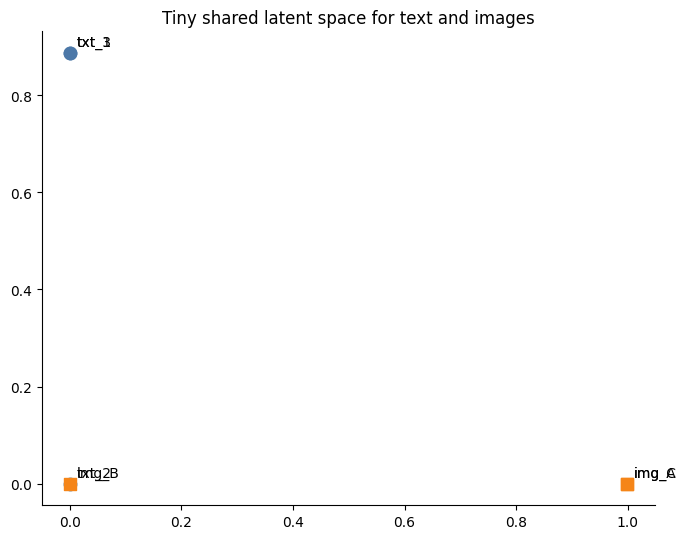

In [26]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for i, name in enumerate(joint_names):
    color = "#4C78A8" if name.startswith("txt") else "#F58518"
    marker = "o" if name.startswith("txt") else "s"
    ax.scatter(Z[i,0], Z[i,1], c=color, marker=marker, s=80)
    ax.annotate(name, (Z[i,0], Z[i,1]), xytext=(5,5), textcoords="offset points")

ax.set_title("Tiny shared latent space for text and images")
plt.tight_layout()
plt.show()


## 11. Compact recap for class

This final cell prints the key outputs in one place.


In [27]:
print("Top document similarities:")
print(sim_report("m1", "m2", doc_coords, doc_names))
print(sim_report("g1", "g2", doc_coords, doc_names))
print(sim_report("g1", "m1", doc_coords, doc_names))

print("\nTop query retrieval results for: 'user response time'")
display(ranking.head(5))

print("\nTakeaway:")
print("- TF-IDF gives a sparse term-document matrix")
print("- SVD / truncated SVD creates a lower-dimensional latent space")
print("- Cosine similarity in that space captures semantic closeness")
print("- The same idea extends beyond text to visual words and multimodal data")


Top document similarities:
m1 vs m2: 0.99
g1 vs g2: 1.00
g1 vs m1: -0.10

Top query retrieval results for: 'user response time'


,doc,title,cosine_with_query
4,m5,Relation of user perceived response time to error measurement,0.999965
0,m1,Human machine interface for ABC computer applications,0.999252
2,m3,The EPS user interface management system,0.999186
3,m4,System and human system engineering testing of EPS,0.998190
1,m2,A survey of user opinion of computer system response time,0.994227



Takeaway:
- TF-IDF gives a sparse term-document matrix
- SVD / truncated SVD creates a lower-dimensional latent space
- Cosine similarity in that space captures semantic closeness
- The same idea extends beyond text to visual words and multimodal data
